In [239]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression , Lasso ,Ridge,ElasticNet
from sklearn.linear_model import LassoCV,RidgeCV,ElasticNetCV
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

In [240]:
df=pd.read_csv(r"C:\Users\Dell\Downloads\Ecommerce Customers (1)")
df

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092
...,...,...,...,...,...,...,...,...
495,lewisjessica@craig-evans.com,"4483 Jones Motorway Suite 872\nLake Jamiefurt,...",Tan,33.237660,13.566160,36.417985,3.746573,573.847438
496,katrina56@gmail.com,"172 Owen Divide Suite 497\nWest Richard, CA 19320",PaleVioletRed,34.702529,11.695736,37.190268,3.576526,529.049004
497,dale88@hotmail.com,"0787 Andrews Ranch Apt. 633\nSouth Chadburgh, ...",Cornsilk,32.646777,11.499409,38.332576,4.958264,551.620145
498,cwilson@hotmail.com,"680 Jennifer Lodge Apt. 808\nBrendachester, TX...",Teal,33.322501,12.391423,36.840086,2.336485,456.469510


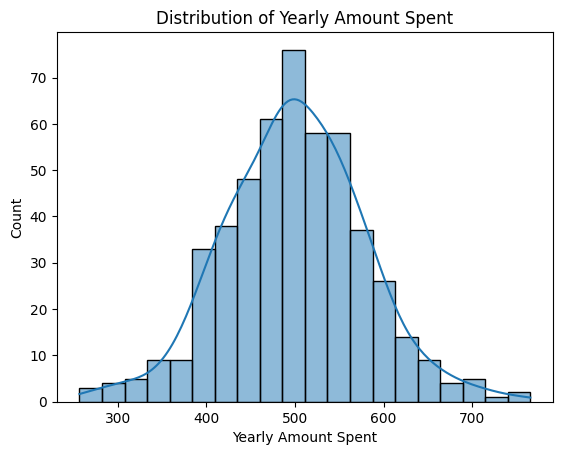

In [241]:
sns.histplot(df['Yearly Amount Spent'], kde=True)
plt.title('Distribution of Yearly Amount Spent')
plt.show()


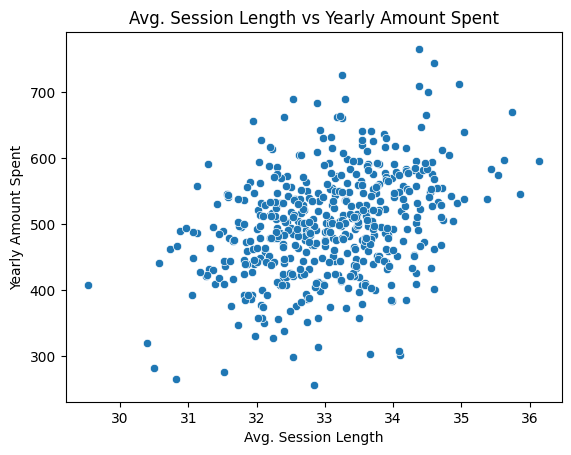

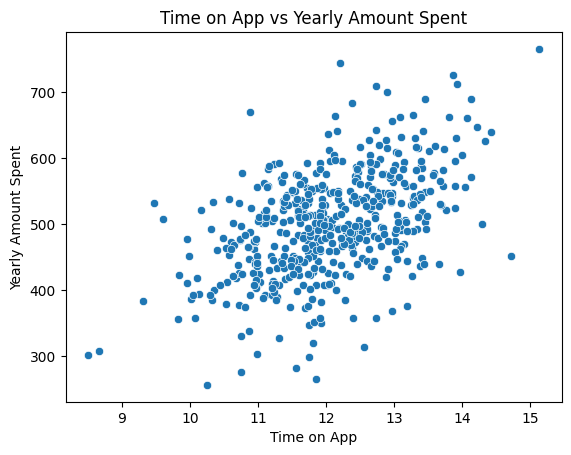

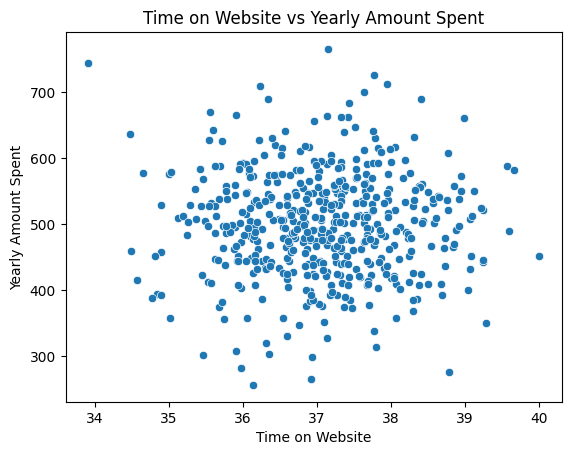

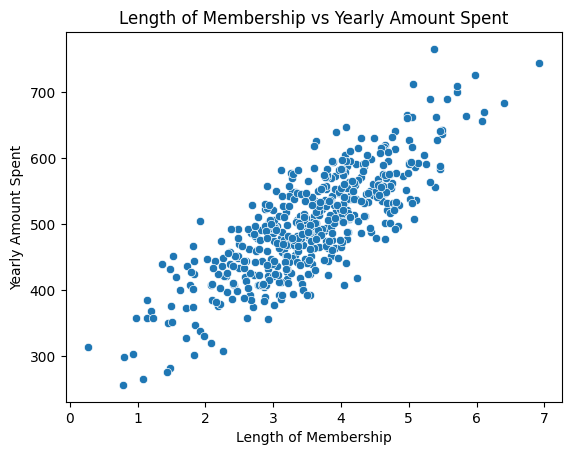

In [270]:
features = ['Avg. Session Length', 'Time on App', 'Time on Website', 'Length of Membership']

for col in features:
    sns.scatterplot(x=df[col], y=df['Yearly Amount Spent'])
    plt.title(f'{col} vs Yearly Amount Spent')
    plt.xlabel(col)
    plt.ylabel('Yearly Amount Spent')
    plt.show()


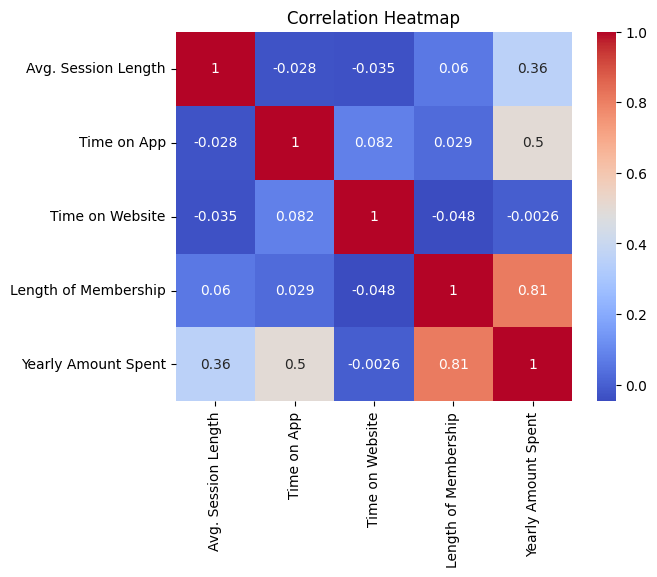

In [ ]:
df_numeric = df.select_dtypes(include=['number'])
sns.heatmap(df_numeric.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [242]:
df.isnull().sum()

Email                   0
Address                 0
Avatar                  0
Avg. Session Length     0
Time on App             0
Time on Website         0
Length of Membership    0
Yearly Amount Spent     0
dtype: int64

In [243]:
df.duplicated().sum()

np.int64(0)

In [244]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), object(3)
memory usage: 31.4+ KB


In [245]:
x=df.drop(["Email","Address","Avatar","Yearly Amount Spent"],axis=1)
y=df["Yearly Amount Spent"]

In [246]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)

In [247]:
s=StandardScaler()

In [248]:
x_train_scaled=s.fit_transform(x_train)
x_train_scaled

array([[ 0.81898265, -0.02177665, -2.46761848,  1.86691469],
       [ 0.87429038, -0.03762014, -0.28806538, -0.80056171],
       [ 1.51059934,  0.12128189,  2.09322728,  0.08501491],
       ...,
       [-1.26027629, -1.15748164, -2.05511356, -0.43528945],
       [-0.80828501,  2.07624947,  0.02789298,  0.18135749],
       [-0.64089425, -0.59762062,  0.57343539, -0.96260714]])

In [249]:
x_test_scaled=s.transform(x_test)
x_test_scaled

array([[-9.92502521e-01, -1.69449304e+00,  2.00901040e+00,
        -1.37474861e-01],
       [-2.54041967e-01,  7.65431158e-01,  3.57912643e-02,
         2.68494058e-01],
       [-1.62898365e+00, -1.93980915e+00,  1.02740360e+00,
         6.44964221e-01],
       [-6.16830358e-01,  1.40362714e+00,  2.38899523e-01,
        -6.17556383e-01],
       [-1.68742659e+00, -1.05058356e+00,  1.05778145e+00,
        -1.43023646e-01],
       [-6.35701242e-01,  1.83155770e+00,  1.35911584e+00,
         1.91967282e-01],
       [ 1.99712575e+00, -1.12423880e-01, -1.18679444e+00,
        -2.58587642e-01],
       [-4.58745785e-02, -2.86527459e-01,  5.63609959e-01,
         2.51546231e-01],
       [-6.35782702e-01, -7.39751778e-01,  6.71637711e-01,
        -7.75156662e-01],
       [-6.24441176e-02, -1.09778686e+00,  6.39696465e-01,
         2.43622850e-01],
       [-1.13496245e+00, -2.33771197e-01,  1.47140636e-01,
        -3.63087511e-01],
       [ 4.03282405e-01, -6.57682175e-01,  8.95784289e-01,
      

In [250]:
l=LinearRegression()
l.fit(x_train_scaled,y_train)

LinearRegression()

In [251]:
y_pred=l.predict(x_test_scaled)
y_pred

array([403.66993069, 542.57756289, 427.06591658, 502.02460425,
       410.12143559, 569.93442508, 531.93431341, 506.29650969,
       408.71870658, 473.97737105, 441.46912726, 425.33703059,
       425.1297229 , 527.61676714, 431.45684016, 424.0769184 ,
       575.76543296, 484.89856554, 458.35936863, 481.96502182,
       502.32441491, 513.63783554, 507.58877002, 646.57464283,
       450.24372141, 496.27043415, 556.40457807, 554.95630839,
       399.64237199, 325.84623136, 532.89783259, 478.12238702,
       501.05701845, 305.97335848, 505.77244448, 483.79591969,
       518.8331528 , 438.18241857, 456.71094234, 471.04609461,
       494.44008972, 445.31155755, 508.78802753, 501.04594193,
       488.83499673, 535.38079541, 595.20129802, 514.04714872,
       280.76758312, 433.10112367, 421.70823427, 481.23640152,
       584.71372272, 608.7748096 , 563.98513427, 494.72804869,
       394.52133407, 456.4197529 , 573.08767515, 499.6984241 ,
       512.83277025, 392.12434043, 480.05057697, 481.54

In [252]:
score=r2_score(y_test,y_pred)
score

0.9808757641125856

In [253]:
score_2=1-((1-score)*(len(x_test)-1)/(len(x_test)-x_test.shape[1]-1))
score_2

0.980348198984657

In [254]:
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

103.91554136503315
8.426091641432098
10.193897260863146


In [255]:
laso=Lasso()
laso.fit(x_train_scaled,y_train)
y_pred=laso.predict(x_test_scaled)
score=r2_score(y_test,y_pred)
score

0.9803859742065482

In [256]:
score_2=1-((1-score)*(len(x_test)-1)/(len(x_test)-x_test.shape[1]-1))
score_2

0.9798448976329357

In [257]:
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

106.57691740853274
8.46025586482621
10.323609708262548


In [258]:
r=Ridge()
r.fit(x_train_scaled,y_train)

Ridge()

In [259]:
y_pred=r.predict(x_test_scaled)
score=r2_score(y_test,y_pred)
score

0.980870403012211

In [260]:
score_2=1-((1-score)*(len(x_test)-1)/(len(x_test)-x_test.shape[1]-1))
score_2

0.9803426899918581

In [261]:
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

103.94467202682877
8.423742930734338
10.195325989237851


In [262]:
elastic=ElasticNet()
elastic.fit(x_train_scaled,y_train)
y_pred=elastic.predict(x_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
score

0.873652031508644

In [263]:
score_2=1-((1-score)*(len(x_test)-1)/(len(x_test)-x_test.shape[1]-1))
score_2

0.8701665703088824

In [264]:
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

686.5381510375462
20.658884696742614
26.20187304445135


In [265]:
lassocv=LassoCV(cv=5)
lassocv.fit(x_train_scaled,y_train)

LassoCV(cv=5)

In [266]:
y_pred=lassocv.predict(x_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)

Mean absolute error 8.423617762334034
R2 Score 0.9808738943569252


In [267]:
ridgecv=RidgeCV(cv=5)
ridgecv.fit(x_train_scaled,y_train)
y_pred=ridgecv.predict(x_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)

Mean absolute error 8.425856209765767
R2 Score 0.9808758828177467


In [268]:
elasticcv=ElasticNetCV(cv=5)
elasticcv.fit(x_train_scaled,y_train)
y_pred=elasticcv.predict(x_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)

Mean absolute error 9.103400079327542
R2 Score 0.977314443540935
